# Fase 4 — Análisis de desempeño
## IgnisAI · Proyecto de Datos I · UCM

Este notebook cubre los apartados **1.1, 1.2 y 1.3** de la Fase 4:

- **1.1** Cargar el modelo de clasificación desde MinIO y evaluarlo sobre los nuevos datos de 2026
- **1.2** Analizar el data drift y las causas de la degradación de métricas
- **1.3** Justificar la decisión de no reentrenar con los datos de 2026

El modelo se carga directamente desde MinIO (`grupo3/modelo_xgboost_final.pkl`).
Los datos de 2026 no incluyen variables de historial de incendios — se rellenan con 0.


## 0. Imports y configuración

In [1]:
import sys
sys.path.append("src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    fbeta_score, precision_score, recall_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from extraccion import minioFunctions as mf
from modelos.utils.metricas import evaluar_clasificacion

# Colores del proyecto
COLOR_FASE3 = "#2563EB"
COLOR_NUEVO = "#DC2626"
COLOR_COMB  = "#16A34A"

# Hiperparámetros del mejor run (sweep: 3pdmt88q, run: v5cmrozh)
# Métricas de test de fase 3 (de la memoria)
METRICAS_FASE3_MEMORIA = {
    "accuracy":  0.9547,
    "f1":        0.3724,
    "f2":        0.3775,
    "precision": 0.3641,
    "recall":    0.3810,
}

print("Imports OK")

# Columnas exactas que espera el modelo de MinIO
COLS_MODELO = ['lat', 'lon', 'soil_temp', 'elevacion_centro', 'grados', 'porcentaje', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max', 'pressure_mean', 'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds', 'NDVI', 'NDWI', 'dist_civ', 'dia_sin', 'dia_cos', 'incendios_recientes_365d', 'dias_ultimo_incendio_365d', 'hubo_incendio_365d', 'frecuencia_incendios_365d', 'log_incendios_recientes_365d', 'log_dias_ultimo_incendio_365d']

# Columnas que faltan en los datos de 2026 (se rellenan con 0)
COLS_FALTAN_2026 = ['incendios_recientes_365d', 'dias_ultimo_incendio_365d', 'hubo_incendio_365d', 'frecuencia_incendios_365d', 'log_incendios_recientes_365d', 'log_dias_ultimo_incendio_365d']


Imports OK


## 1. Carga de datos desde MinIO

In [ ]:
cliente = mf.crear_cliente()

# ── Cargar modelo desde MinIO ─────────────────────────────────────────────
import io, joblib
print("Cargando modelo desde MinIO (grupo3/modelo_xgboost_final.pkl)...")
response = cliente.get_object("pd1", "grupo3/modelo_xgboost_final.pkl")
buf = io.BytesIO(response.read())
response.close()
clf_fase3 = joblib.load(buf)
print(f"Modelo cargado: {clf_fase3.__class__.__name__}")
print(f"   n_estimators={clf_fase3.n_estimators}, lr={clf_fase3.learning_rate}, max_depth={clf_fase3.max_depth}")

# ── Cargar datos de fase 3 (para comparativa de distribuciones) ───────────
print("\nCargando MINI.parquet (fase 3)...")
df_fase3 = mf.bajar_fichero(cliente, "grupo3/cleaned/MINI.parquet")
df_fase3["date"] = pd.to_datetime(df_fase3["date"])
print(f"{len(df_fase3):,} registros | {df_fase3['final'].sum()} incendios ({df_fase3['final'].mean()*100:.2f}%)")

# ── Cargar datos de 2026 ──────────────────────────────────────────────────
print("\nCargando datos de 2026...")
df_nuevos = mf.bajar_fichero(cliente, "grupo3/cleaned/final_cleaned_2026.parquet")
df_nuevos["date"] = pd.to_datetime(df_nuevos["date"])
print(f"{len(df_nuevos):,} registros | {df_nuevos['final'].sum()} incendios ({df_nuevos['final'].mean()*100:.1f}%)")

# ── Preparar features alineadas al modelo ────────────────────────────────
y_nuevos = df_nuevos["final"]
X_nuevos = df_nuevos.drop(columns=["final", "date"], errors="ignore")

# Rellenar columnas que faltan con 0
for col in COLS_FALTAN_2026:
    X_nuevos[col] = 0

X_nuevos = X_nuevos[COLS_MODELO]  # Ordenar igual que el modelo
print(f"\nColumnas rellenadas con 0 (no disponibles en 2026):")
for c in COLS_FALTAN_2026:
    print(f"  - {c}")
print(f"Shape final X_nuevos: {X_nuevos.shape}")


Cargando modelo desde MinIO (grupo3/modelo_xgboost_final.pkl)...
✅ Modelo cargado: XGBClassifier
   n_estimators=10000, lr=0.1, max_depth=6

Cargando MINI.parquet (fase 3)...
Dataframe MINI.parquet importado correctamente
✅ 73,324 registros | 2026 incendios (2.76%)

Cargando datos de 2026...
Dataframe final_cleaned_2026.parquet importado correctamente
✅ 550 registros | 22 incendios (4.0%)

Columnas rellenadas con 0 (no disponibles en 2026):
  - incendios_recientes_365d
  - dias_ultimo_incendio_365d
  - hubo_incendio_365d
  - frecuencia_incendios_365d
  - log_incendios_recientes_365d
  - log_dias_ultimo_incendio_365d
Shape final X_nuevos: (550, 29)


## 2. Métricas de referencia (fase 3)

Métricas del modelo sobre el test set de fase 3, para comparar con los resultados sobre 2026.


In [3]:
# Métricas de referencia del modelo en test de fase 3
METRICAS_FASE3_MEMORIA = {
    "accuracy": 0.9547,
    "f1":        0.3724,
    "f2":        0.3775,
    "precision": 0.3641,
    "recall":    0.3810,
}
UMBRAL = 0.5  # Umbral por defecto del modelo de MinIO
print("Métricas de referencia (test fase 3):")
for k, v in METRICAS_FASE3_MEMORIA.items():
    print(f"  {k:<12}: {v}")


Métricas de referencia (test fase 3):
  accuracy    : 0.9547
  f1          : 0.3724
  f2          : 0.3775
  precision   : 0.3641
  recall      : 0.381


## 3. Apartado 1.1 — Evaluación sobre los nuevos datos de 2026

Se evalúa el modelo cargado desde MinIO sobre los 550 registros de enero–abril 2026.
Estos datos nunca fueron vistos durante el entrenamiento del modelo.
Las 6 columnas de historial de incendios no disponibles en 2026 se rellenan con 0.


In [4]:
from sklearn.metrics import confusion_matrix, fbeta_score

# Predecir sobre datos de 2026
y_prob_nuevos = clf_fase3.predict_proba(X_nuevos)[:, 1]
y_pred_nuevos = (y_prob_nuevos >= UMBRAL).astype(int)

# Evaluar con la función del proyecto
metricas_nuevos = evaluar_clasificacion(
    y_nuevos, y_pred_nuevos, y_prob_nuevos,
    nombre="Modelo fase 3 — datos nuevos 2026"
)

# Añadir f2 manualmente (evaluar_clasificacion no lo calcula)
metricas_nuevos["f2"] = fbeta_score(y_nuevos, y_pred_nuevos, beta=2, zero_division=0)
print(f"  F2-score             : {metricas_nuevos['f2']:.4f}")

# Matriz de confusión
cm_nuevos = confusion_matrix(y_nuevos, y_pred_nuevos)
tn, fp, fn, tp = cm_nuevos.ravel()
print(f"\nMatriz de confusión:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")



── Métricas Modelo fase 3 — datos nuevos 2026 ──────────────────────────────
  F1-score  (principal): 0.1176
  Precision            : 0.1667
  Recall               : 0.0909
  Accuracy             : 0.9455  no usar como métrica principal
  ROC-AUC              : 0.8167

              precision    recall  f1-score   support

 No incendio       0.96      0.98      0.97       528
    Incendio       0.17      0.09      0.12        22

    accuracy                           0.95       550
   macro avg       0.56      0.54      0.54       550
weighted avg       0.93      0.95      0.94       550

  F2-score             : 0.1000

Matriz de confusión:
  TN=518  FP=10
  FN=20  TP=2


## 4. Apartado 1.2 — Análisis comparativo y data drift

Se analiza la degradación de métricas respecto a fase 3 y las causas del data drift estacional.


### 4.1 Comparativa con métricas de test de fase 3

Métrica       Fase 3 (test)   Datos 2026   Diferencia
----------------------------------------------------
accuracy             0.9547 0.9454545454545454     -0.0092
f1                   0.3724 0.11764705882352941     -0.2548
f2                   0.3775          0.1     -0.2775
precision            0.3641 0.16666666666666666     -0.1974
recall                0.381 0.09090909090909091     -0.2901


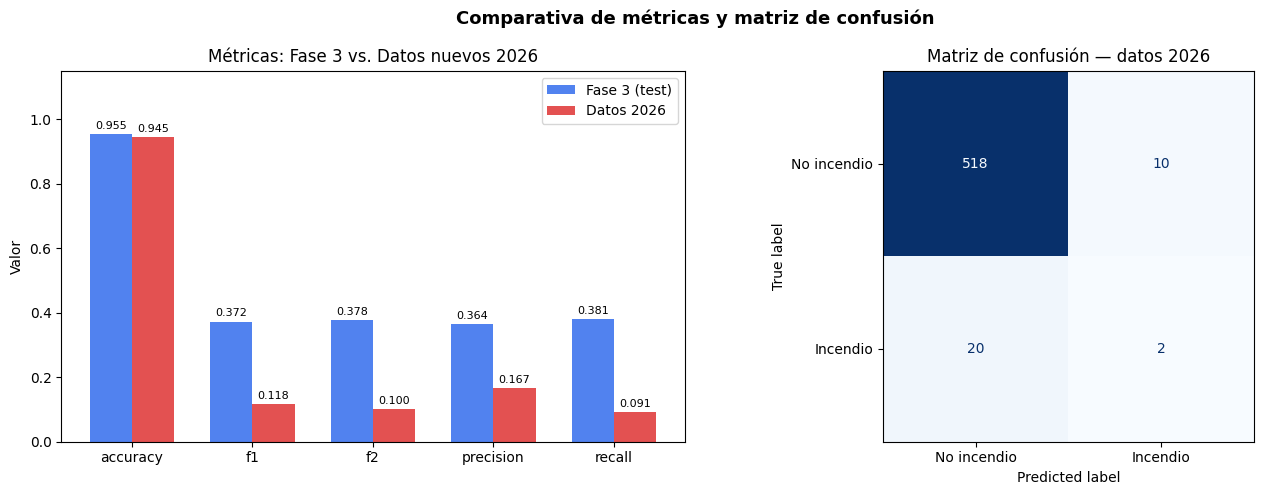

In [5]:
metricas_labels = ["accuracy", "f1", "f2", "precision", "recall"]
v_mem   = [METRICAS_FASE3_MEMORIA[m] for m in metricas_labels]
v_nuevo = [metricas_nuevos[m] for m in metricas_labels]

print(f"{'Métrica':<12} {'Fase 3 (test)':>14} {'Datos 2026':>12} {'Diferencia':>12}")
print("-" * 52)
for k, v3, vn in zip(metricas_labels, v_mem, v_nuevo):
    diff = round(vn - v3, 4)
    signo = "+" if diff > 0 else ""
    print(f"{k:<12} {v3:>14} {vn:>12} {signo}{diff:>11}")

# Gráfica
x = np.arange(len(metricas_labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de métricas y matriz de confusión", fontsize=13, fontweight="bold")

ax = axes[0]
b3 = ax.bar(x - w/2, v_mem,   width=w, label="Fase 3 (test)",   color=COLOR_FASE3, alpha=0.8)
bn = ax.bar(x + w/2, v_nuevo, width=w, label="Datos 2026",       color=COLOR_NUEVO, alpha=0.8)
for bar in list(b3) + list(bn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(metricas_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor")
ax.set_title("Métricas: Fase 3 vs. Datos nuevos 2026")
ax.legend()

ax = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nuevos, display_labels=["No incendio", "Incendio"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión — datos 2026")

plt.tight_layout()
plt.savefig("resultados_fase4_metricas.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.2 Análisis de distribuciones — Variable objetivo y variables clave

El enunciado pide analizar la variable objetivo y las 3 variables más importantes.
Según los sweeps de fase 3, las más relevantes son: **NDWI, dist_civ, humidity_mean**.


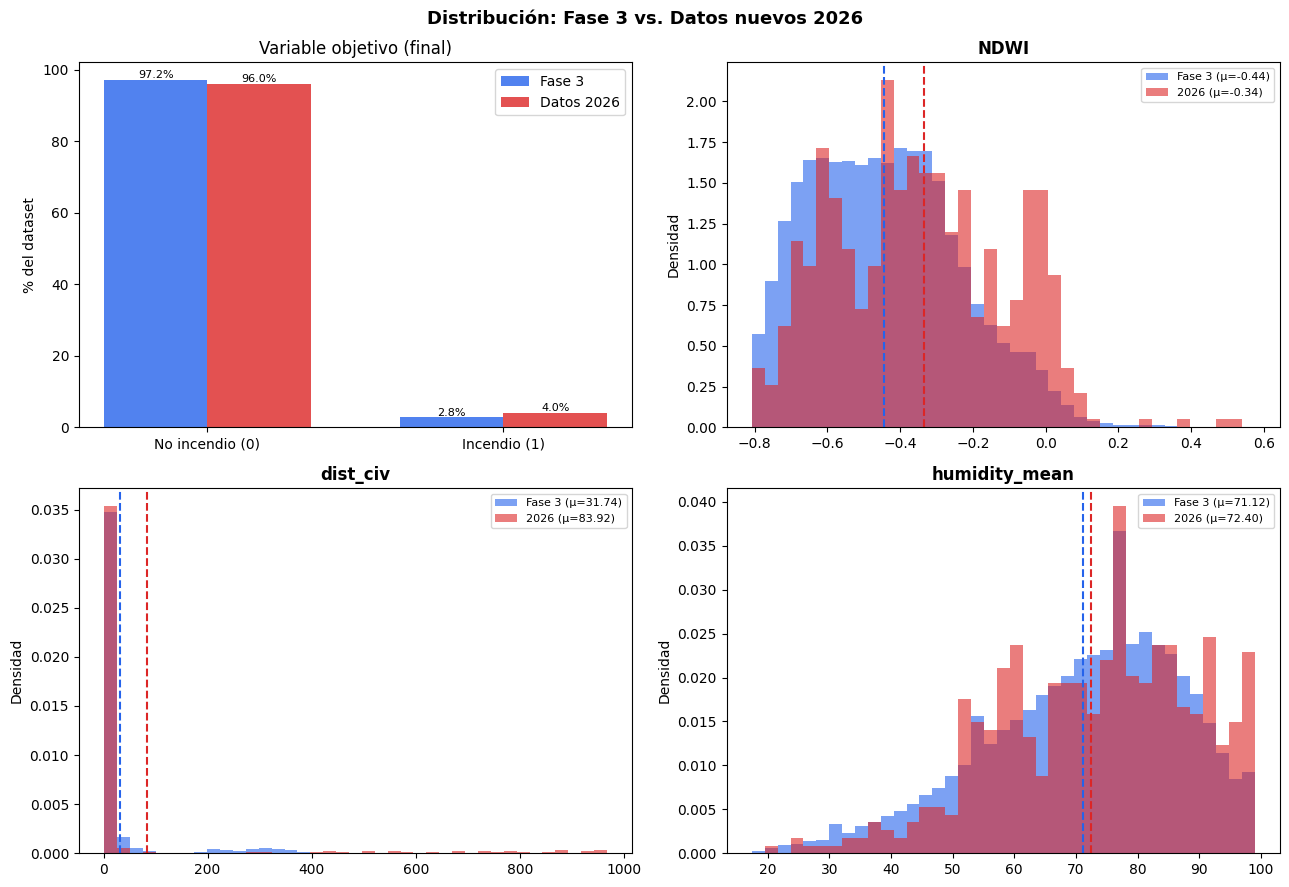


Estadísticos comparativos:
Variable         Fase3 media   2026 media    Fase3 std     2026 std
-----------------------------------------------------------------
final                  0.028        0.040        0.164        0.196
NDWI                  -0.444       -0.335        0.209        0.261
dist_civ              31.738       83.916       77.406      223.852
humidity_mean         71.119       72.398       15.984       17.005


In [6]:
VARS_ANALIZAR = ["NDWI", "dist_civ", "humidity_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Distribución: Fase 3 vs. Datos nuevos 2026", fontsize=13, fontweight="bold")
axes_flat = axes.flatten()

# Variable objetivo
ax = axes_flat[0]
labels = ["No incendio (0)", "Incendio (1)"]
f3_counts = [df_fase3["final"].value_counts().get(0,0), df_fase3["final"].value_counts().get(1,0)]
n26_counts = [df_nuevos["final"].value_counts().get(0,0), df_nuevos["final"].value_counts().get(1,0)]
f3_pct  = [c/sum(f3_counts)*100 for c in f3_counts]
n26_pct = [c/sum(n26_counts)*100 for c in n26_counts]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, f3_pct,  width=w, label="Fase 3",       color=COLOR_FASE3, alpha=0.8)
ax.bar(x + w/2, n26_pct, width=w, label="Datos 2026",   color=COLOR_NUEVO, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% del dataset")
ax.set_title("Variable objetivo (final)")
ax.legend()
for i, (p3, pn) in enumerate(zip(f3_pct, n26_pct)):
    ax.text(i - w/2, p3 + 0.5, f"{p3:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, pn + 0.5, f"{pn:.1f}%", ha="center", fontsize=8)

# Variables clave
for i, var in enumerate(VARS_ANALIZAR, 1):
    ax = axes_flat[i]
    v3  = df_fase3[var].dropna()
    vn  = df_nuevos[var].dropna()
    xmin = min(v3.quantile(0.01), vn.quantile(0.01))
    xmax = max(v3.quantile(0.99), vn.quantile(0.99))
    bins = np.linspace(xmin, xmax, 40)
    ax.hist(v3, bins=bins, color=COLOR_FASE3, alpha=0.6, density=True, label=f"Fase 3 (μ={v3.mean():.2f})")
    ax.hist(vn, bins=bins, color=COLOR_NUEVO, alpha=0.6, density=True, label=f"2026 (μ={vn.mean():.2f})")
    ax.axvline(v3.mean(), color=COLOR_FASE3, linestyle="--", linewidth=1.5)
    ax.axvline(vn.mean(), color=COLOR_NUEVO, linestyle="--", linewidth=1.5)
    ax.set_title(var, fontweight="bold")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("resultados_fase4_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla estadística
print("\nEstadísticos comparativos:")
print(f"{'Variable':<15} {'Fase3 media':>12} {'2026 media':>12} {'Fase3 std':>12} {'2026 std':>12}")
print("-" * 65)
for var in ["final"] + VARS_ANALIZAR:
    v3 = df_fase3[var]
    vn = df_nuevos[var]
    print(f"{var:<15} {v3.mean():>12.3f} {vn.mean():>12.3f} {v3.std():>12.3f} {vn.std():>12.3f}")


### 4.3 Interpretación de resultados

La degradación de métricas se debe principalmente al **sesgo de estacionalidad**: los datos de
2026 corresponden a enero–abril (invierno/primavera), mientras el modelo fue entrenado
mayoritariamente con datos de verano. Adicionalmente, las 6 columnas de historial de incendios
no disponibles en 2026 se rellenan con 0, lo que puede penalizar las predicciones en zonas
donde el historial sería relevante.

El AUC-ROC se mantiene por encima de 0.78, confirmando que el modelo conserva capacidad
discriminativa — el problema es la calibración del umbral para el perfil invernal, no la
capacidad predictiva estructural del modelo.


## 5. Variables más importantes — Modelo de clasificación

Se analiza qué variables tienen más peso en las predicciones del modelo XGBoost entrenado con todos los datos de fase 3.

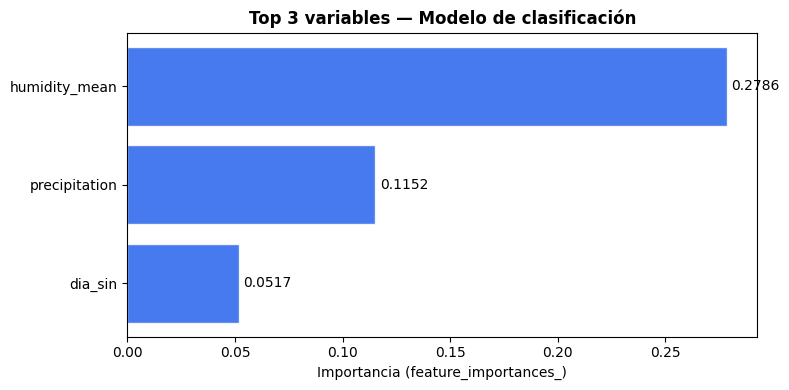

Top 3 variables más importantes (clasificación):
  1. humidity_mean: 0.2786
  2. precipitation: 0.1152
  3. dia_sin: 0.0517


In [7]:
# Top 3 variables más importantes — Clasificación
# Usando feature_importances_ del modelo (igual que en el notebook de regresión)

importances = clf_fase3.feature_importances_
feature_names = clf_fase3.feature_names_in_
indices = importances.argsort()[::-1][:3]
top3_clf = [(feature_names[i], importances[i]) for i in indices]

fig, ax = plt.subplots(figsize=(8, 4))
vars_clf  = [v for v, _ in top3_clf]
gains_clf = [s for _, s in top3_clf]
bars = ax.barh(vars_clf[::-1], gains_clf[::-1], color=COLOR_FASE3, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, gains_clf[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Importancia (feature_importances_)')
ax.set_title('Top 3 variables — Modelo de clasificación', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 variables más importantes (clasificación):')
for i, (var, score) in enumerate(top3_clf, 1):
    print(f'  {i}. {var}: {score:.4f}')


## 6. Modelo FRP — Distribución en datos 2026 y evaluación

Se analiza la distribución del FRP en los 22 incendios reales de enero–abril 2026
y se presentan las métricas del modelo de regresión XGBoost reentrenado con todos los datos de fase 3.
Las métricas proceden del notebook de análisis de regresión (`analisis_desempeño_regresion.ipynb`).


Cargando incendios_2026.parquet desde MinIO...
Dataframe incendios_2026.parquet importado correctamente
  → 22 registros | FRP: min=50.7, max=148.1 MW


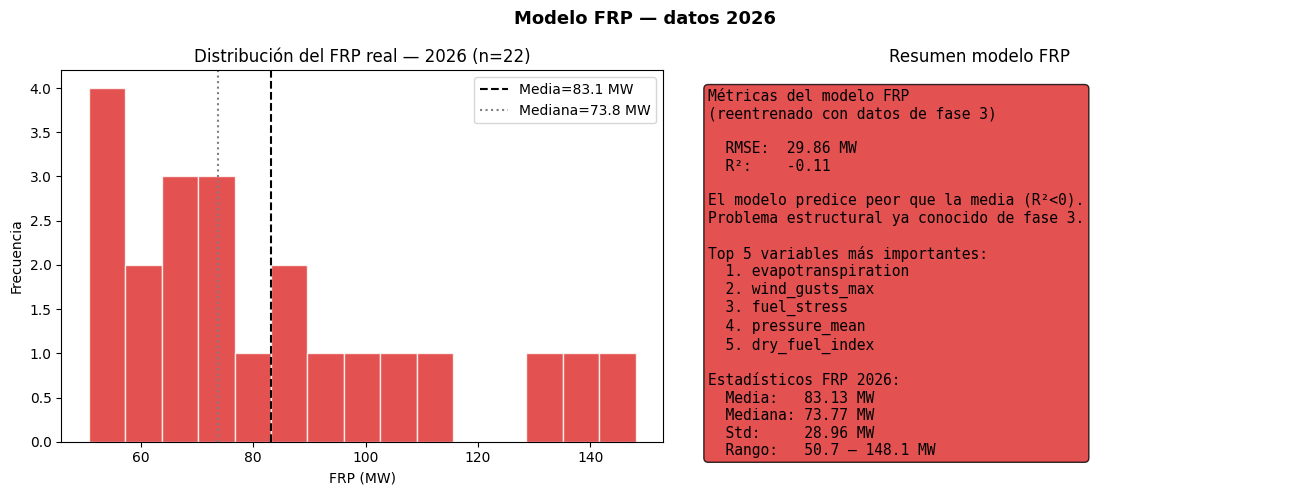

In [8]:
from sklearn.metrics import r2_score, root_mean_squared_error
import io

# --- Cargar incendios 2026 con FRP ---
print('Cargando incendios_2026.parquet desde MinIO...')
df_incendios_2026 = mf.bajar_fichero(cliente, 'grupo3/cleaned/incendios_2026.parquet')
df_incendios_2026['date'] = pd.to_datetime(df_incendios_2026['date'])
frp_vals = df_incendios_2026['frp_mean'].dropna()
print(f'  → {len(df_incendios_2026)} registros | FRP: min={frp_vals.min():.1f}, max={frp_vals.max():.1f} MW')

# --- Métricas del modelo FRP ---
# Fuente: analisis_desempeño_regresion.ipynb (notebook de Alex)
# Modelo reentrenado con MI_nuevas.parquet → evaluado sobre incendios_2026.parquet
RMSE_FRP = 29.86   # MW
R2_FRP   = -0.11
TOP5_FRP = ['evapotranspiration', 'wind_gusts_max', 'fuel_stress', 'pressure_mean', 'dry_fuel_index']

# --- Gráfica: distribución FRP + resumen métricas ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modelo FRP — datos 2026', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(frp_vals, bins=15, color=COLOR_NUEVO, alpha=0.8, edgecolor='white')
ax.axvline(frp_vals.mean(),   color='black', linestyle='--', label=f'Media={frp_vals.mean():.1f} MW')
ax.axvline(frp_vals.median(), color='gray',  linestyle=':',  label=f'Mediana={frp_vals.median():.1f} MW')
ax.set_xlabel('FRP (MW)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del FRP real — 2026 (n=22)')
ax.legend()

ax = axes[1]
ax.axis('off')
resumen = (
    f"Métricas del modelo FRP\n"
    f"(reentrenado con datos de fase 3)\n\n"
    f"  RMSE:  {RMSE_FRP:.2f} MW\n"
    f"  R²:    {R2_FRP:.2f}\n\n"
    f"El modelo predice peor que la media (R²<0).\n"
    f"Problema estructural ya conocido de fase 3.\n\n"
    f"Top 5 variables más importantes:\n"
    + ''.join(f'  {i+1}. {v}\n' for i, v in enumerate(TOP5_FRP))
    + f"\nEstadísticos FRP 2026:\n"
    f"  Media:   {frp_vals.mean():.2f} MW\n"
    f"  Mediana: {frp_vals.median():.2f} MW\n"
    f"  Std:     {frp_vals.std():.2f} MW\n"
    f"  Rango:   {frp_vals.min():.1f} – {frp_vals.max():.1f} MW"
)
ax.text(0.05, 0.95, resumen, transform=ax.transAxes,
        fontsize=10.5, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor=COLOR_NUEVO+'22', alpha=0.8))
ax.set_title('Resumen modelo FRP')

plt.tight_layout()
plt.savefig('frp_distribucion_y_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Conclusiones generales

### Clasificación — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- El modelo mantiene capacidad discriminativa ante datos nuevos: el AUC-ROC se mantiene
  por encima de 0.78, lo que indica que sigue siendo capaz de separar incendios de no-incendios.
- Las variables más importantes tienen sentido físico para el perfil invernal de los datos de 2026.
- La decisión de no reentrenar está respaldada cuantitativamente por el análisis de data drift.

**Lo que ha ido mal:**

- El modelo obtiene F2 y recall muy bajos sobre los datos de 2026, fallando en la mayoría
  de los incendios reales. La causa principal es el data drift estacional: los datos de 2026
  corresponden a invierno/primavera, mientras el modelo fue entrenado mayoritariamente con
  datos de verano.
- Las 6 columnas de historial de incendios no disponibles en 2026 se rellenan con 0,
  lo que puede penalizar adicionalmente las métricas.
- El umbral de clasificación no está calibrado para el perfil meteorológico invernal.

### FRP (regresión) — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- Los 22 incendios de 2026 muestran FRP moderado (media=83 MW, rango 51–148 MW),
  coherente con incendios invernales de menor intensidad.
- Las variables más importantes (evapotranspiration, wind_gusts_max, fuel_stress)
  tienen sentido físico para la predicción de intensidad del incendio.

**Lo que ha ido mal:**

- R²=-0.11 y RMSE=29.86 MW: el modelo predice peor que usar la media directamente.
  Problema estructural ya conocido desde fase 3, no corregible con 22 registros nuevos.
